# MVSA

## Data cleaning

You may change the *label_file* and corresponding variables for the respective MVSA Single and Multiple datasets.

In [3]:
import re
from collections import Counter

label_file = "/kaggle/input/mvsamultiple/MVSA/labelResultAll.txt"  # adjust path as needed

def get_majority_text(text_list):
    counts = Counter(text_list).most_common()
    if len(counts) > 1 and counts[0][1] == counts[1][1]:
        return "neutral"  # Tie case
    return counts[0][0]

sentiments = []
count = 0

with open(label_file, "r", encoding="utf-8") as f:
    for line in f:
        if "ID" in line:
            continue  # skip header
        count+=1
        parts = re.split(r'[\n\t]', line.strip())
        parts = list(filter(None, parts))  # remove empty strings
        annotators = parts[1:]  # ignore the ID
        img_sent = [ann.split(",")[1] for ann in annotators]  # get image sentiment
        majority_sentiment = get_majority_text(img_sent)
        sentiments.append(majority_sentiment)

# Example: print first few results
print(sentiments[:5])

['positive', 'positive', 'neutral', 'positive', 'neutral']


In [4]:
len(sentiments)

19600

In [5]:
from PIL import Image
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches

client = vision.ImageAnnotatorClient()

In [6]:
# bool([0])
root = "/kaggle/input/mvsamultiple/MVSA/data"

In [8]:
import cv2
from tqdm.notebook import tqdm

all_files = os.listdir(root)
images = [file for file in all_files if "jpg" in file]
images.sort()

text_detected, filename, filepath, ocr, coordinates = [],[],[],[],[]
txt_height, txt_width, img_height, img_width = [],[],[],[]


for image_name in tqdm(images, desc="Processing images (MVSA-Multiple)", unit="image"):
    # if image_name!="100.jpg":
    #     continue
    # print(image_name)
    # break
    fpath = os.path.join(root, image_name)

    with io.open(fpath, 'rb') as image_file:
        content = image_file.read()
    img_w, img_h = None,None
    try:
        img_w, img_h = (Image.open(io.BytesIO(content))).size
        continue
        # img_w, img_h = img.size
    except:
        indices+=[index]
        continue
    # img_w, img_h = (Image.open(io.BytesIO(content))).size
    # print(img_w, img_h)
    img_width+=[img_w]
    img_height+=[img_h]

    coords,h,w = [],0,0
    
    image = vision.Image(content=content)
    response = client.text_detection(image=image)
    texts = response.text_annotations

    if texts:
        text = texts[0].description
        bounding_poly = texts[0].bounding_poly
        for vertex in bounding_poly.vertices:
            coords.append({"x": vertex.x, "y": vertex.y})
        x_vals, y_vals = [],[]
        x_vals = [p['x'] for p in coords]
        y_vals = [p['y'] for p in coords]
        x_min, y_min, x_max, y_max = min(x_vals),min(y_vals),max(x_vals),max(y_vals)
        h,w = y_max - y_min,x_max - x_min
    else:
        text = ""
    txt_height+=[h]
    txt_width+=[w]
    
    filename+=[image_name]
    filepath+=[fpath]
    flag = bool(texts)
    text_detected+=[flag]
    
    ocr+=[text]
    coordinates+=[coords]


print("DONE......................!!!")


    # print("Google Vision OCR")
    # print("______________________________")
    # print(texts[0])

    # print("\nOur derivatives")
    # print("______________________________")
    # print(f"Filename: {image_name}")
    # print(f"Filepath: {fpath}")
    # print(f"Text detected: {flag}")
    # print(f"OCR: {text}")
    # print(f"Coordinates: {coords}")
    # print(f"Txt H: {h}")
    # print(f"Txt W: {w}")
    # print(f"Img H: {img_h}")
    # print(f"Img W: {img_w}")
    
    # print("______________________________\n")
    # img = Image.open(fpath)
    # plt.imshow(img)
    # plt.axis('off')
    # plt.savefig("mvsa-single-example.png")
    # plt.show()
    
    
    # img = cv2.imread(fpath)
    # Draw rectangle on image
    # cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color=(255, 0, 0), thickness=2)
    
    # Show image
    # plt.imshow(img)
    # plt.axis('off')
    # plt.title("Bounding Box on Image")
    # plt.savefig("mvsa-single-example-bdBox.png")
    # plt.show()
    # break

Processing images (MVSA-Multiple):   0%|          | 0/19600 [00:00<?, ?image/s]

DONE......................!!!


In [26]:
filename[:5]

['10000.jpg', '10001.jpg', '10002.jpg', '10003.jpg', '10004.jpg']

In [30]:
missing = []

for image_name in tqdm(images, desc=f"Finding corrupted images (MVSA-Multiple):", unit="image"):
    if image_name not in filename:
        missing+=[image_name]

print(f"Missing filenames are: {missing}")

Finding corrupted images (MVSA-Multiple)::   0%|          | 0/19600 [00:00<?, ?image/s]

Missing filenames are: ['3151.jpg', '3910.jpg', '5995.jpg']


In [33]:
# images.index('3151.jpg')

for name in missing:
    index = images.index(name)
    del sentiments[index]

print(f"Length of sentiments list: {len(sentiments)}")

Length of sentiments list: 19597


In [34]:
# text_detected, filename, filepath, ocr, coordinates = [],[],[],[],[]
# txt_height, txt_width, img_height, img_width = [],[],[],[]
mvsa_multiple_info = pd.DataFrame({
    "filename":filename,
    "filepath":filepath,
    "img_height":img_height,
    "img_width":img_width,
    "text_detected":text_detected,
    "ocr":ocr,
    "coordinates":coordinates,
    "text_height":txt_height,
    "text_width":txt_width,
    "sentiment":sentiments
})

mvsa_multiple_info.to_csv("mvsa_multiple_info.csv", index=False)

In [35]:
len(mvsa_multiple_info[mvsa_multiple_info["text_detected"]==True])

12866

## Orientation analysis

In [36]:
# Define standard aspect ratios
standard_ratios = {
    "1:1": 1.0, # 1 BOX
    "4:3": 4/3, # 1.33 Horizontal
    "3:2": 3/2, # 1.5 Horizontal
    "16:9": 16/9, # 1.78 Horizontal
    "17:9": 17/9, # 1.93 Horizontal
    "5:4": 5/4, # 1.25 Horizontal
    "21:9": 21/9, # 2.33 Horizontal
    "2:1": 2.0, # 2 Horizontal
    "7:5": 7/5, # 1.4 Horizontal
    # "A4 (1.41:1)": 1.41,
    "3:4": 3/4, # 0.75 Vertical
    "2:3": 2/3, # 0.67 Vertical
    "9:16": 9/16, # 0.5625 Vertical
    "5:7": 5/7, # 0.71 Vertical
    "4:5": 4/5, # 0.8 Vertical
    "A-series (1:√2)": 1/1.414, # 0.707 Vertical
    "2:5": 2/5, # 0.4 Vertical
    "1:3": 1/3, # 0.33 Vertical
    "Other":0
}

# Function to match image to closest standard aspect ratio
def closest_standard_ratio(width, height, tolerance=0.10):
    if height == 0:
        return "Invalid"
    ratio = width / height
    for name, std_ratio in standard_ratios.items():
        if abs(ratio - std_ratio) <= tolerance:
            return name
    return "Other"


ar_columnNames = list(standard_ratios.keys())
rowNames = ["positive", "negative", "neutral"]

txt_ar_df = pd.DataFrame(0, index=rowNames, columns=ar_columnNames)
img_ar_df = pd.DataFrame(0, index=rowNames, columns=ar_columnNames)

aspect_ratio_orientation = {
    # --- Box-like (almost square) ---
    "1:1": "box",

    # --- Horizontal (landscape) ---
    "4:3": "horizontal",      # 1.33
    "3:2": "horizontal",      # 1.5
    "16:9": "horizontal",     # 1.78
    "17:9": "horizontal",     # 1.93
    "5:4": "horizontal",      # 1.25
    "21:9": "horizontal",     # 2.33
    "2:1": "horizontal",      # 2.0
    "7:5": "horizontal",      # 1.4
    "A4 (1.41:1)": "horizontal",  # 1.41

    # --- Vertical (portrait) ---
    "3:4": "vertical",        # 0.75
    "2:3": "vertical",        # 0.666
    "9:16": "vertical",       # 0.5625
    "5:7": "vertical",        # 0.714
    "4:5": "vertical",        # 0.8
    "A-series (1:√2)": "vertical",  # ≈0.707
    "2:5": "vertical",        # 0.4
    "1:3": "vertical",

    # --- Catch-all ---
    # "Other": "other"
    "Other": "box"
}



# Helper function to classify orientation
def get_orientation(aspect_ratio="Other"):
    return aspect_ratio_orientation[aspect_ratio]




columnNames = ["horizontal", "box","vertical"]
rowNames = ["positive", "negative", "neutral"]

# Create a DataFrame filled with zeros
txt_orientation_df = pd.DataFrame(0, index=rowNames, columns=columnNames)
img_orientation_df = pd.DataFrame(0, index=rowNames, columns=columnNames)

In [38]:
img_w_txt=0

L = len(mvsa_multiple_info)

for i in tqdm(range(L), desc="Orientation Analysis (MVSA-Multiple)", unit="image"):
    if not mvsa_multiple_info.iloc[i]["text_detected"]: # False
        continue
    img_w_txt+=1
    row = mvsa_multiple_info.iloc[i]
    img_w, img_h = row["img_width"],row["img_height"]
    txt_w, txt_h = row["text_width"],row["text_height"]
    
    txt_ar = closest_standard_ratio(txt_w, txt_h)
    img_ar = closest_standard_ratio(img_w, img_h)
    
    txt_orientation = aspect_ratio_orientation[txt_ar]
    img_orientation = aspect_ratio_orientation[img_ar]
    
    img_ar_df.loc[row['sentiment'],img_ar]+=1
    txt_ar_df.loc[row['sentiment'],txt_ar]+=1
    
    img_orientation_df.loc[row['sentiment'],img_orientation]+=1
    txt_orientation_df.loc[row['sentiment'],txt_orientation]+=1

print("Done!")

Orientation Analysis (MVSA-Multiple):   0%|          | 0/19597 [00:00<?, ?image/s]

Done!


In [14]:
img_w_txt

2813

In [39]:
img_orientation_df

,horizontal,box,vertical
positive,2715,1879,1996
negative,343,258,291
neutral,2263,1536,1585


In [40]:
from scipy.stats import chi2_contingency

def chisq_test_orientation(data, alpha=0.05):
    sentiments = ['positive', 'negative', 'neutral']
    orientations = ['horizontal', 'box', 'vertical']
    
    chi2, p, dof, expected = chi2_contingency(data)
    print()
    print(f"Chi-square statistic = {chi2:.3f}")
    print(f"p-value = {p}")
    print(f"Degrees of freedom = {dof}")
    print()
    print("Expected frequencies:")
    print(pd.DataFrame(np.round(expected, 2), index=sentiments, columns=orientations))
    # Decision
    # alpha = 0.05
    if p < alpha:
        print("Reject the null hypothesis: There is a relationship between orientation and sentiment.")
    else:
        print("Fail to reject the null hypothesis: No significant relationship found.")

In [41]:
datasets = [img_orientation_df, txt_orientation_df]

for i,data in enumerate(datasets):
    print("_"*50)
    print(f"Dataset {i}")
    print("_"*100)
    print("Original frequencies:\n",data)
    los = 0.05
    print(f"Chosen level of significance = {los}")
    chisq_test_orientation(data, los)

__________________________________________________
Dataset 0
____________________________________________________________________________________________________
Original frequencies:
           horizontal   box  vertical
positive        2715  1879      1996
negative         343   258       291
neutral         2263  1536      1585
Chosen level of significance = 0.05

Chi-square statistic = 5.246
p-value = 0.26299390634082254
Degrees of freedom = 4

Expected frequencies:
          horizontal      box  vertical
positive     2725.43  1881.32   1983.25
negative      368.91   254.65    268.45
neutral      2226.66  1537.03   1620.31
Fail to reject the null hypothesis: No significant relationship found.
__________________________________________________
Dataset 1
____________________________________________________________________________________________________
Original frequencies:
           horizontal   box  vertical
positive        1941  3085      1564
negative         263   410       21

In [54]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [55]:
os.listdir('./../../file/dataset_mvsa-info/')

['mvsa-m.csv', 'mvsa-s.csv']

In [56]:
os.listdir('./../../visualization/mvsa-s/')

['consensus__mvsa-s.png', 'sd__mvsa-s.png', 'mvsas_textpercentage.png']

In [57]:
root = './../../file/dataset_mvsa-info/'

## MVSA-Single

In [58]:
m1 = pd.read_csv(root+'mvsa-s.csv')
m1

,filename,filepath,img_height,img_width,text_detected,ocr,coordinates,text_height,text_width,sentiment
0,1.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/1.jpg,325,551,True,ONE DOES NOT SIMPLY\nWALK AFTER LEG DAY\nquick...,"[{'x': 56, 'y': 18}, {'x': 549, 'y': 18}, {'x'...",306,493,positive
1,10.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/10.jpg,450,600,False,NaN,[],0,0,positive
2,100.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/100.jpg,337,599,True,GHIRARDELLI\nCHOCOLATE\nSQUARES\nCaramel\nFili...,"[{'x': 172, 'y': 21}, {'x': 514, 'y': 21}, {'x...",266,342,positive
3,1000.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/1000...,600,600,True,C,"[{'x': 277, 'y': 331}, {'x': 346, 'y': 331}, {...",63,69,positive
4,1001.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/1001...,961,436,True,Nig what u saying\niMessage,"[{'x': 21, 'y': 470}, {'x': 158, 'y': 470}, {'...",478,137,positive
...,...,...,...,...,...,...,...,...,...,...
4864,995.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/995.jpg,65,65,False,NaN,[],0,0,positive
4865,996.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/996.jpg,800,600,True,SL,"[{'x': 319, 'y': 638}, {'x': 376, 'y': 638}, {...",43,57,neutral
4866,997.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/997.jpg,600,600,False,NaN,[],0,0,positive
4867,998.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/998.jpg,1024,577,False,NaN,[],0,0,positive


In [59]:
noText1 = m1[m1["ocr"].isna()]
Text1 = m1[m1["ocr"].notna()]

In [60]:
type(m1["ocr"][1])

float

In [61]:
noText1

,filename,filepath,img_height,img_width,text_detected,ocr,coordinates,text_height,text_width,sentiment
1,10.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/10.jpg,450,600,False,NaN,[],0,0,positive
5,1002.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/1002...,387,600,False,NaN,[],0,0,positive
13,101.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/101.jpg,800,600,False,NaN,[],0,0,positive
17,1013.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/1013...,640,480,False,NaN,[],0,0,positive
18,1014.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/1014...,1024,576,False,NaN,[],0,0,negative
...,...,...,...,...,...,...,...,...,...,...
4860,991.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/991.jpg,448,395,False,NaN,[],0,0,positive
4862,993.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/993.jpg,450,600,False,NaN,[],0,0,negative
4864,995.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/995.jpg,65,65,False,NaN,[],0,0,positive
4866,997.jpg,/kaggle/input/mvsasingle/MVSA_Single/data/997.jpg,600,600,False,NaN,[],0,0,positive


In [62]:
len_noText1 = len(noText1)
len_Text1 = len(m1) - len_noText1

In [63]:
len_noText1

2056

In [64]:
len(m1)

4869

In [65]:
len_Text1

2813

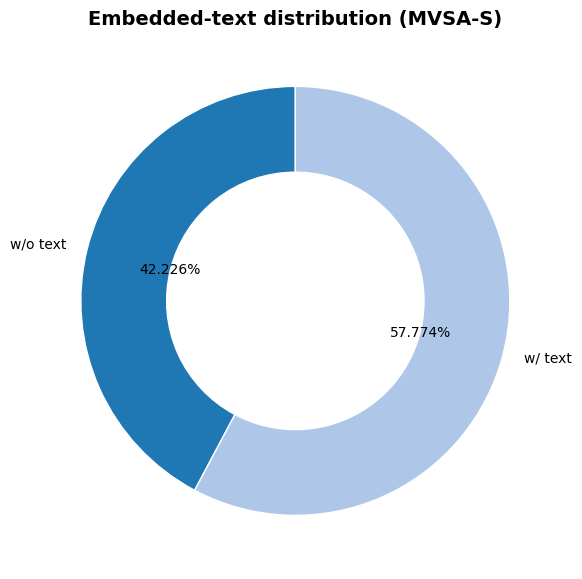

In [77]:
import matplotlib.pyplot as plt

# Example class distribution
labels = ['w/o text', 'w/ text']
sizes = [len_noText1, len_Text1]  # replace with your actual counts or percentages

# Blue-themed colors
colors = ['#1f77b4', '#aec7e8']  # dark blue, light blue

fig, ax = plt.subplots(figsize=(6, 6))

# Donut (hollow) pie chart
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=lambda p: '{:.3f}%'.format(p),
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white')
)

# Equal aspect ratio ensures circular shape
ax.set(aspect="equal")

# Optional title
ax.set_title('Embedded-text distribution (MVSA-S)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./../../visualization/mvsa-s/mvsas_textpercentage.png')
plt.show()

## MVSA-Multiple

In [67]:
m2 = pd.read_csv(root+'mvsa-m.csv')
m2

,filename,filepath,img_height,img_width,text_detected,ocr,coordinates,text_height,text_width,sentiment
0,10000.jpg,/kaggle/input/mvsamultiple/MVSA/data/10000.jpg,450,600,False,NaN,[],0,0,positive
1,10001.jpg,/kaggle/input/mvsamultiple/MVSA/data/10001.jpg,448,600,True,NotinOurName\nLING\nFRACK\n@CDHILLS,"[{'x': 7, 'y': 6}, {'x': 599, 'y': 6}, {'x': 5...",437,592,positive
2,10002.jpg,/kaggle/input/mvsamultiple/MVSA/data/10002.jpg,41,75,True,PC,"[{'x': 14, 'y': 5}, {'x': 70, 'y': 5}, {'x': 7...",28,56,neutral
3,10003.jpg,/kaggle/input/mvsamultiple/MVSA/data/10003.jpg,450,600,True,GPAC\nGas Processing\nAssociation Canada\nAllies,"[{'x': 303, 'y': 87}, {'x': 485, 'y': 87}, {'x...",190,182,positive
4,10004.jpg,/kaggle/input/mvsamultiple/MVSA/data/10004.jpg,261,600,True,O\nOxford Dictionaries\nLanguage matters\nCana...,"[{'x': 9, 'y': 2}, {'x': 596, 'y': 2}, {'x': 5...",249,587,neutral
...,...,...,...,...,...,...,...,...,...,...
19592,9994.jpg,/kaggle/input/mvsamultiple/MVSA/data/9994.jpg,800,600,False,NaN,[],0,0,negative
19593,9995.jpg,/kaggle/input/mvsamultiple/MVSA/data/9995.jpg,450,600,True,beral\nLiberal Liberal stil\nLiberal out Liber...,"[{'x': 13, 'y': 53}, {'x': 271, 'y': 53}, {'x'...",175,258,neutral
19594,9996.jpg,/kaggle/input/mvsamultiple/MVSA/data/9996.jpg,1024,576,False,NaN,[],0,0,positive
19595,9997.jpg,/kaggle/input/mvsamultiple/MVSA/data/9997.jpg,44,375,True,Low/Bas 11.3 27.6 51.6\nSpadina Fort York 11.9...,"[{'x': 105, 'y': 3}, {'x': 364, 'y': 3}, {'x':...",37,259,neutral


In [68]:
noText2 = m2[m2["ocr"].isna()]
Text2 = m2[m2["ocr"].notna()]

In [69]:
type(m2["ocr"][1])

str

In [70]:
noText2

,filename,filepath,img_height,img_width,text_detected,ocr,coordinates,text_height,text_width,sentiment
0,10000.jpg,/kaggle/input/mvsamultiple/MVSA/data/10000.jpg,450,600,False,NaN,[],0,0,positive
6,10006.jpg,/kaggle/input/mvsamultiple/MVSA/data/10006.jpg,480,600,False,NaN,[],0,0,neutral
8,10008.jpg,/kaggle/input/mvsamultiple/MVSA/data/10008.jpg,392,599,False,NaN,[],0,0,neutral
14,10014.jpg,/kaggle/input/mvsamultiple/MVSA/data/10014.jpg,314,397,False,NaN,[],0,0,positive
21,10021.jpg,/kaggle/input/mvsamultiple/MVSA/data/10021.jpg,216,284,False,NaN,[],0,0,neutral
...,...,...,...,...,...,...,...,...,...,...
19578,9980.jpg,/kaggle/input/mvsamultiple/MVSA/data/9980.jpg,600,600,False,NaN,[],0,0,neutral
19587,9989.jpg,/kaggle/input/mvsamultiple/MVSA/data/9989.jpg,399,599,False,NaN,[],0,0,positive
19590,9992.jpg,/kaggle/input/mvsamultiple/MVSA/data/9992.jpg,209,241,False,NaN,[],0,0,positive
19592,9994.jpg,/kaggle/input/mvsamultiple/MVSA/data/9994.jpg,800,600,False,NaN,[],0,0,negative


In [71]:
len_noText2 = len(noText2)
len_Text2 = len(m2) - len_noText2

In [73]:
len_noText2

6731

In [74]:
len(m2)

19597

In [75]:
len_Text2

12866

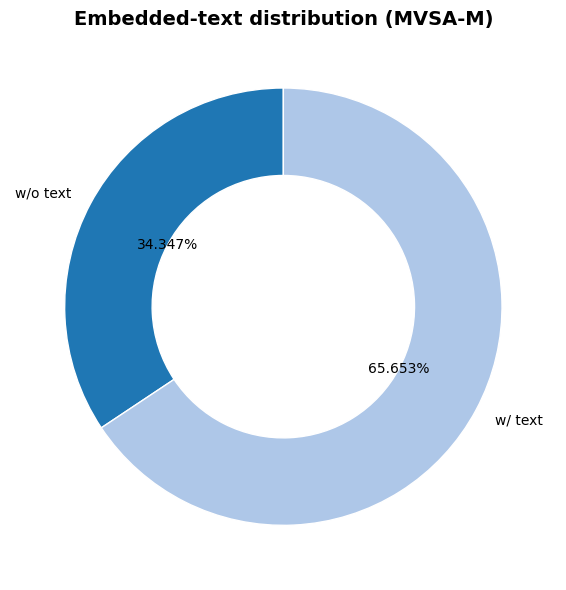

In [78]:
import matplotlib.pyplot as plt

# Example class distribution
labels = ['w/o text', 'w/ text']
sizes = [len_noText2, len_Text2]  # replace with your actual counts or percentages

# Blue-themed colors
colors = ['#1f77b4', '#aec7e8']  # dark blue, light blue

fig, ax = plt.subplots(figsize=(6, 6))

# Donut (hollow) pie chart
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=lambda p: '{:.3f}%'.format(p),
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white')
)

# Equal aspect ratio ensures circular shape
ax.set(aspect="equal")

# Optional title
ax.set_title('Embedded-text distribution (MVSA-M)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./../../visualization/mvsa-m/mvsam_textpercentage.png')
plt.show()